# Xenium Human Lung — Spatial Transcriptomics with Squidpy

**Dataset:** 10x Xenium V1 Human Lung 2-FOV (sub-cellular resolution, ~161 000 cells × 480 genes)  
**Data source:** https://cf.10xgenomics.com

### Pipeline
| Step | Task |
|------|------|
| 1 | Install packages — **no version pins, pip resolves automatically** |
| 2 | Download + unzip the Xenium dataset |
| 3 | Load with `spatialdata-io` — in memory, no Zarr write |
| 4 | Extract AnnData, inspect metadata |
| 5 | QC metrics + histograms |
| 6 | Filter cells and genes |
| 7 | Normalise → log → PCA → UMAP → Leiden clustering |
| 8 | UMAP + spatial scatter plots |
| 9 | Build spatial neighbourhood graph |
| 10 | Centrality scores |
| 11 | Co-occurrence probability |
| 12 | Neighbourhood enrichment |
| 13 | Moran's I — spatially variable genes |
| 14 | Visualise top spatially variable genes |

> ⚠️ **After Cell 1 finishes, go to `Runtime → Restart session`, then run from Cell 2.**

## Cell 1 — Install Packages


⏳ Takes ~3–4 minutes. **Restart runtime when done.**

In [11]:
import sys

# Install with NO version pins — pip resolves the latest compatible stack
!{sys.executable} -m pip install -q \
    spatialdata \
    spatialdata-io \
    squidpy \
    scanpy \
    seaborn \
    leidenalg

print("\n✅ Installation complete.")
print("👉 Go to  Runtime → Restart session  then run from Cell 2.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 44.2 MB/s eta 0:00:00

✅ Installation complete.
👉 Go to  Runtime → Restart session  then run from Cell 2.


## Cell 2 — Import Libraries

Import the full analysis stack. Warnings are suppressed to keep output clean.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc
import squidpy as sq
import spatialdata as sd
from spatialdata_io import xenium

sc.settings.verbosity = 1

print(f"scanpy       : {sc.__version__}")
print(f"squidpy      : {sq.__version__}")
print(f"spatialdata  : {sd.__version__}")
print(f"anndata      : {ad.__version__}")

scanpy       : 1.12.1
squidpy      : 1.8.1
spatialdata  : 0.7.2
anndata      : 0.12.11


## Cell 3 — Download the Xenium Dataset

Downloads **Xenium V1 Human Lung 2-FOV** (~3 GB) directly from the 10x Genomics public server and extracts it into `./Xenium/`. A guard skips the download if the folder already exists.

In [2]:
XENIUM_DIR = "./Xenium"
ZIP_FILE   = "Xenium_outs.zip"
URL = (
    "https://cf.10xgenomics.com/samples/xenium/2.0.0/"
    "Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip"
)

if not os.path.exists(XENIUM_DIR):
    print("Downloading dataset (~3 GB) — may take 5–15 min ...")
    !wget -q --show-progress "{URL}" -O "{ZIP_FILE}"
    print("Extracting ...")
    !unzip -q "{ZIP_FILE}" -d "{XENIUM_DIR}"
    !rm -f "{ZIP_FILE}"
    print("Done!")
else:
    print("Xenium/ already exists — skipping download.")

print("\nFolder contents:")
!ls "{XENIUM_DIR}"

Xenium_outs.zip     100%[===================>] 265.12M   253MB/s    in 1.0s    
Extracting ...
Done!

Folder contents:
analysis_summary.html	      cells.zarr.zip
analysis.tar.gz		      experiment.xenium
analysis.zarr.zip	      gene_panel.json
aux_outputs.tar.gz	      metrics_summary.csv
cell_boundaries.csv.gz	      morphology_focus
cell_boundaries.parquet       morphology.ome.tif
cell_feature_matrix.h5	      nucleus_boundaries.csv.gz
cell_feature_matrix.tar.gz    nucleus_boundaries.parquet
cell_feature_matrix.zarr.zip  transcripts.csv.gz
cells.csv.gz		      transcripts.parquet
cells.parquet		      transcripts.zarr.zip


## Cell 4 — Load Data In-Memory (No Images, No Zarr Write)

We load with `spatialdata_io.xenium()` with images disabled and **never call `sdata.write()`**.

**Why this matters:**

The morphology TIFF images (20 000 × 51 000 px, multi-scale) are loaded lazily by dask with **irregular chunk shapes** — e.g. `((1,), (3553,), (4096, 1695))`. The Zarr library rejects these when writing because it expects a uniform `(int, int, int)` shape. This caused:
```
TypeError: Expected an iterable of integers. Got ((1,), (3553,), (4096, 1695))
```
Disabling images and skipping `sdata.write()` eliminates this error completely. The count matrix, cell shapes, and labels all load and work perfectly without the images.

In [3]:
print("Loading Xenium data into memory (no images, no Zarr write) ...")

sdata = xenium(
    XENIUM_DIR,
    morphology_focus=False,   # skip: causes Zarr chunk error
    morphology_mip=False,     # skip: causes Zarr chunk error
    aligned_images=False,     # skip: any aligned H&E or IF images
    transcripts=False,        # skip: raw transcript point cloud (very large)
)

print("\nLoaded successfully:")
print(sdata)

Loading Xenium data into memory (no images, no Zarr write) ...

Loaded successfully:
SpatialData object
├── Labels
│     ├── 'cell_labels': DataTree[yx] (3553, 5791), (1776, 2895), (888, 1447), (444, 723), (222, 361)
│     └── 'nucleus_labels': DataTree[yx] (3553, 5791), (1776, 2895), (888, 1447), (444, 723), (222, 361)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (11898, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (11898, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (11898, 289)
with coordinate systems:
    ▸ 'global', with elements:
        cell_labels (Labels), nucleus_labels (Labels), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)


## Cell 5 — Extract AnnData Table

Gene expression is stored in `sdata.tables` as an `AnnData` object:

| Slot | Contents |
|------|----------|
| `adata.X` | Cells × genes count matrix |
| `adata.obs` | Per-cell metadata: transcript counts, cell area, nucleus area … |
| `adata.obsm["spatial"]` | (x, y) tissue coordinates for each cell |

The table key can vary between versions of `spatialdata-io`, so we use a safe lookup.

In [4]:
# Safely get the table regardless of key name
table_keys = list(sdata.tables.keys())
print(f"Available table keys: {table_keys}")

adata = sdata.tables[table_keys[0]]
print(f"\nUsing table: '{table_keys[0]}'")
print(adata)
print("\nObs columns:", adata.obs.columns.tolist())

Available table keys: ['table']

Using table: 'table'
AnnData object with n_obs × n_vars = 11898 × 289
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

Obs columns: ['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels']


In [5]:
# Preview per-cell metadata
adata.obs.head()

,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
0,aaafiiei-1,67,0,0,0,0,67,139.126411,29.125782,cell_circles,5.0,1.0,1
1,aaanbaof-1,69,0,0,0,0,69,154.434381,31.519064,cell_circles,5.0,1.0,2
2,aabdiein-1,63,0,0,0,0,63,148.247974,25.693907,cell_circles,5.0,1.0,3
3,aabfemmf-1,78,0,0,0,0,78,120.251098,33.551095,cell_circles,5.0,1.0,4
4,aacflbgf-1,19,0,0,0,0,19,31.067501,8.128125,cell_circles,5.0,1.0,5


In [6]:
# Verify spatial coordinates are populated
# (spatialdata-io xenium reader sets obsm["spatial"] automatically)
if "spatial" in adata.obsm:
    print("Spatial coords shape:", adata.obsm["spatial"].shape)
    print(adata.obsm["spatial"][:3])
else:
    # Fallback: build from centroid obs columns
    x_col = next((c for c in adata.obs.columns if "x_centroid" in c.lower()), None)
    y_col = next((c for c in adata.obs.columns if "y_centroid" in c.lower()), None)
    if x_col and y_col:
        adata.obsm["spatial"] = np.column_stack(
            [adata.obs[x_col].values, adata.obs[y_col].values]
        )
        print(f"Built spatial coords from '{x_col}' and '{y_col}'")
    else:
        print("WARNING: Could not find spatial coordinates.")
        print("Available obs columns:", adata.obs.columns.tolist())

Spatial coords shape: (11898, 2)
[[ 37.24629974 667.76745605]
 [ 44.10276031 701.72283936]
 [ 40.73135757 684.13360596]]


## Cell 6 — Quality Control Metrics

`sc.pp.calculate_qc_metrics` adds to `adata.obs`:
- `total_counts` — total transcripts per cell
- `n_genes_by_counts` — unique genes detected per cell

Negative control columns (`control_probe_counts`, `control_codeword_counts`) should be < 1 % of total counts, confirming low background noise.

In [7]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

for col in ["control_probe_counts", "control_codeword_counts"]:
    if col in adata.obs.columns:
        pct = adata.obs[col].sum() / adata.obs["total_counts"].sum() * 100
        print(f"{col}: {pct:.4f}%  (good if < 1%)")

control_probe_counts: 0.0025%  (good if < 1%)
control_codeword_counts: 0.0053%  (good if < 1%)


## Cell 7 — QC Histogram Plots

Inspect four QC distributions to choose sensible filtering thresholds:
- **Total transcripts** — very low = empty / dead cells
- **Unique genes** — transcriptomic complexity per cell
- **Cell area** — extreme values = segmentation artefacts
- **Nucleus ratio** — fraction of cell area that is nucleus; outliers = poor segmentation

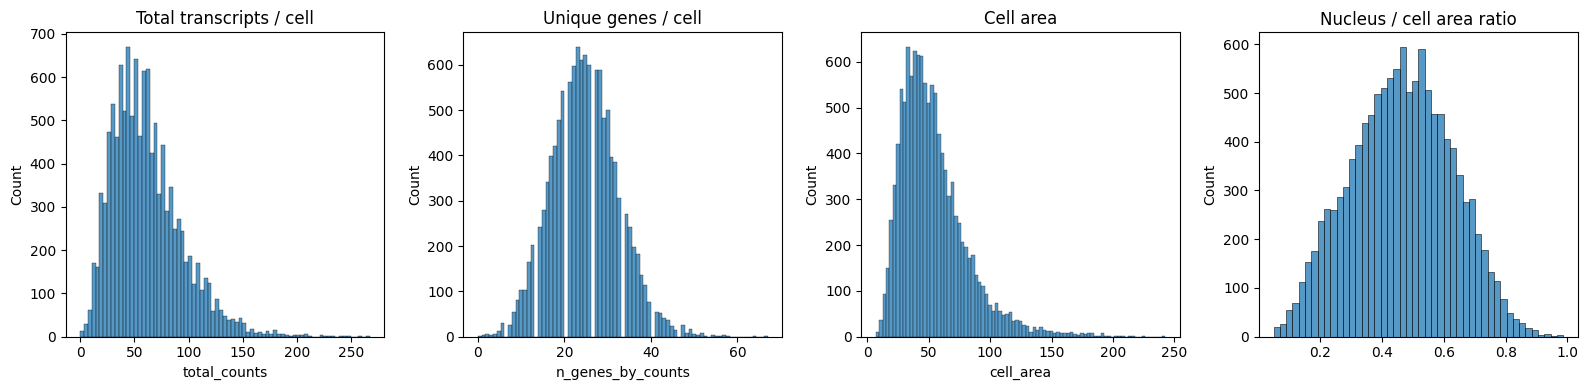

In [8]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].set_title("Total transcripts / cell")
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])

axs[1].set_title("Unique genes / cell")
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, ax=axs[1])

if "cell_area" in adata.obs.columns:
    axs[2].set_title("Cell area")
    sns.histplot(adata.obs["cell_area"], kde=False, ax=axs[2])
else:
    axs[2].set_visible(False)

if "nucleus_area" in adata.obs.columns and "cell_area" in adata.obs.columns:
    axs[3].set_title("Nucleus / cell area ratio")
    sns.histplot(adata.obs["nucleus_area"] / adata.obs["cell_area"], kde=False, ax=axs[3])
else:
    axs[3].set_visible(False)

plt.tight_layout()
plt.show()

## Cell 8 — Filter Cells and Genes

Conservative filters:
- **Cells:** keep ≥ 10 total counts (removes empty / debris)
- **Genes:** expressed in ≥ 5 cells (removes ultra-rare transcripts)

In [9]:
print(f"Before: {adata.n_obs:>8,} cells | {adata.n_vars:>5,} genes")

sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

print(f"After : {adata.n_obs:>8,} cells | {adata.n_vars:>5,} genes")

Before:   11,898 cells |   289 genes
After :   11,820 cells |   285 genes


## Cell 9 — Normalise, Reduce Dimensions, Cluster

Standard Scanpy preprocessing pipeline:

1. **Save raw counts** in `adata.layers["counts"]` before any transformation
2. **`normalize_total`** — equalise library sizes across all cells
3. **`log1p`** — log(x + 1) to compress dynamic range and stabilise variance
4. **`pca`** — linear dimensionality reduction to top 50 PCs
5. **`neighbors`** — k-NN graph in PCA space
6. **`umap`** — 2D non-linear embedding for visualisation
7. **`leiden`** — graph community detection to assign cluster labels

In [12]:
adata.layers["counts"] = adata.X.copy()   # preserve raw counts

sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata)

print(f"Leiden clusters found: {adata.obs['leiden'].nunique()}")

Leiden clusters found: 17


## Cell 10 — UMAP Visualisation

Plot the UMAP embedding coloured by total counts, gene count, and Leiden cluster. Cells close together in UMAP share similar transcriptional profiles.

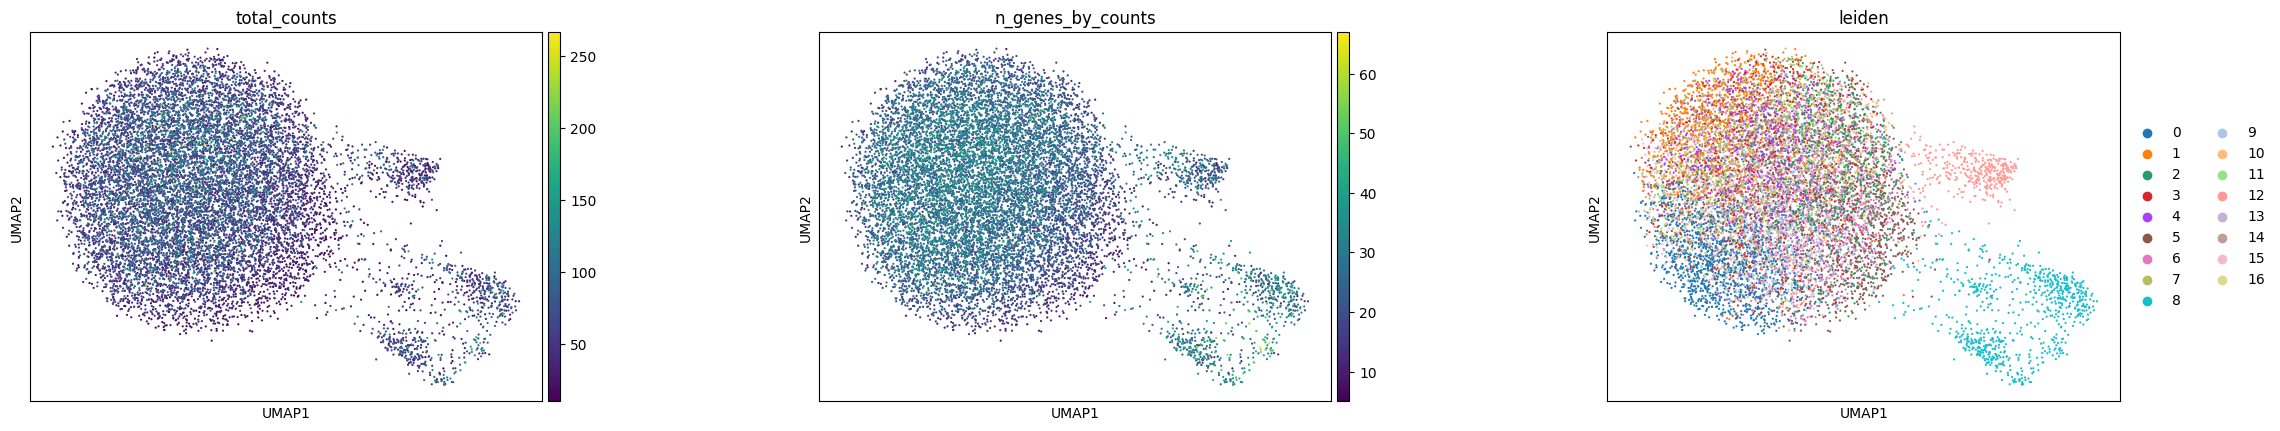

In [13]:
sc.pl.umap(
    adata,
    color=["total_counts", "n_genes_by_counts", "leiden"],
    wspace=0.4,
)

## Cell 11 — Spatial Scatter: Clusters on Tissue

Project Leiden clusters back onto real tissue (x, y) coordinates. Spatial organisation of clusters reveals distinct tissue regions — tumour core, stroma, immune infiltrate, airways, etc.

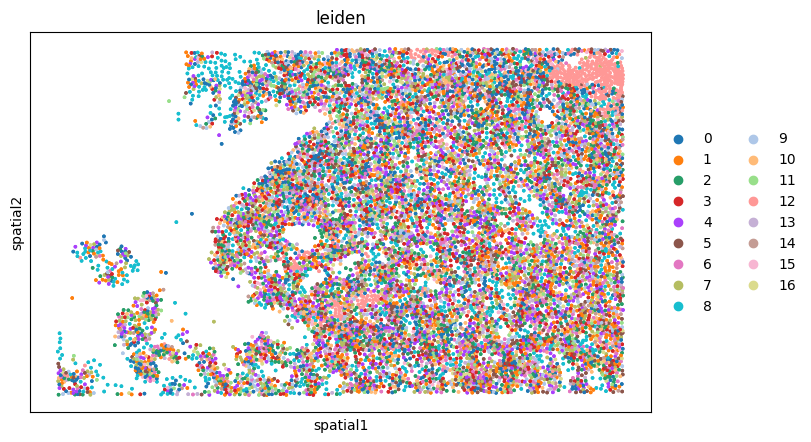

In [14]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=["leiden"],
    figsize=(8, 8),
)

## Cell 12 — Build Spatial Neighbourhood Graph

A connectivity graph connecting each cell to its physically nearest neighbours in tissue space. Required by all Squidpy spatial statistics.

- `coord_type="generic"` — for free-form (x, y) coordinates, not a regular grid
- `delaunay=True` — Delaunay triangulation gives geometrically natural, non-redundant connections

In [15]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

print("Spatial graph built.")
print("Connectivities matrix shape:", adata.obsp["spatial_connectivities"].shape)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
Spatial graph built.
Connectivities matrix shape: (11820, 11820)


## Cell 13 — Centrality Scores

Network-science metrics describing how each cluster is positioned in the spatial graph:

| Metric | Meaning |
|--------|---------|
| **Closeness centrality** | Average distance to all other cells — high = spatially central |
| **Clustering coefficient** | Tendency to form tight local triangles (cliques) |
| **Degree centrality** | Fraction of non-cluster cells directly connected to this cluster |

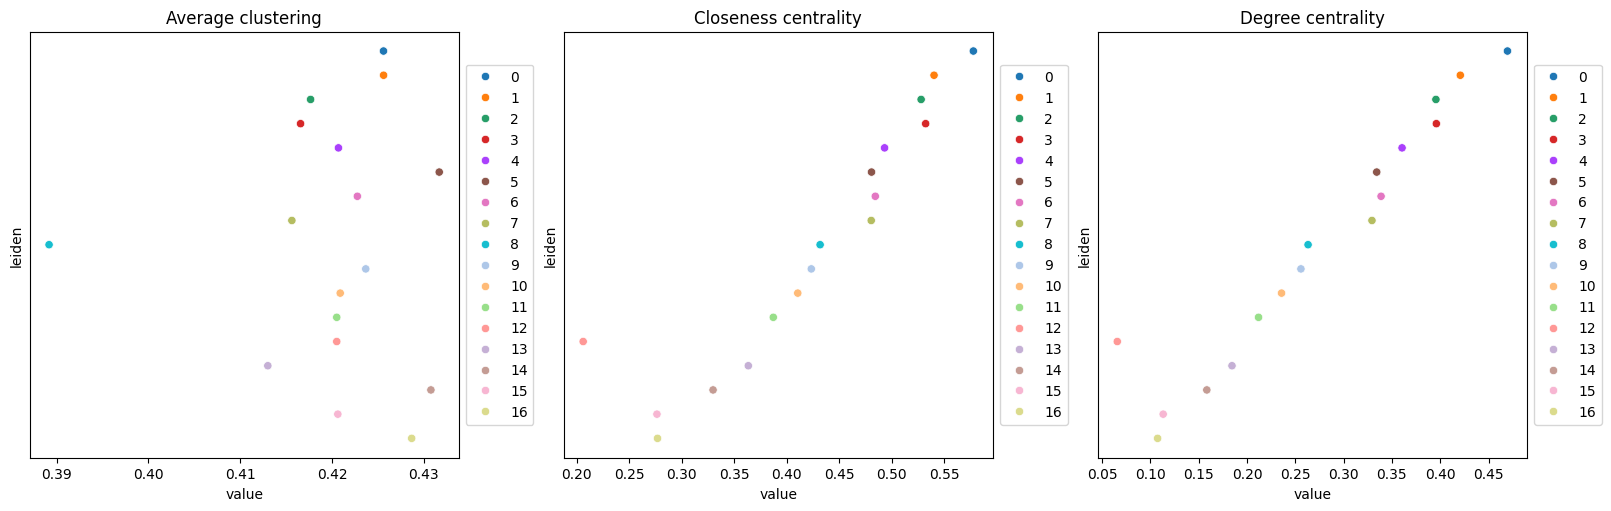

In [16]:
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

## Cell 14 — Subsample for Expensive Analyses

Co-occurrence and Moran's I scale with O(n²) in the number of cells. We subsample 50 % of cells for just these two steps. Everything else uses the full dataset.

In [17]:
adata_sub = sc.pp.subsample(adata, fraction=0.5, copy=True)

print(f"Full dataset : {adata.n_obs:,} cells")
print(f"Subsampled   : {adata_sub.n_obs:,} cells")

Full dataset : 11,820 cells
Subsampled   : 5,910 cells


## Cell 15 — Co-occurrence Probability

Measures how likely it is to find cluster B near cluster A as the spatial radius increases. Operates on raw (x, y) coordinates — not the graph.

$$\text{score}(r) = \frac{p(B \mid A,\, r)}{p(B)}$$

- **> 1** → more co-localised than chance at radius r
- **≈ 1** → random
- **< 1** → spatial avoidance

The conditioning cluster is picked automatically from whatever clusters exist in the subsampled data.

Conditioning on cluster: 3


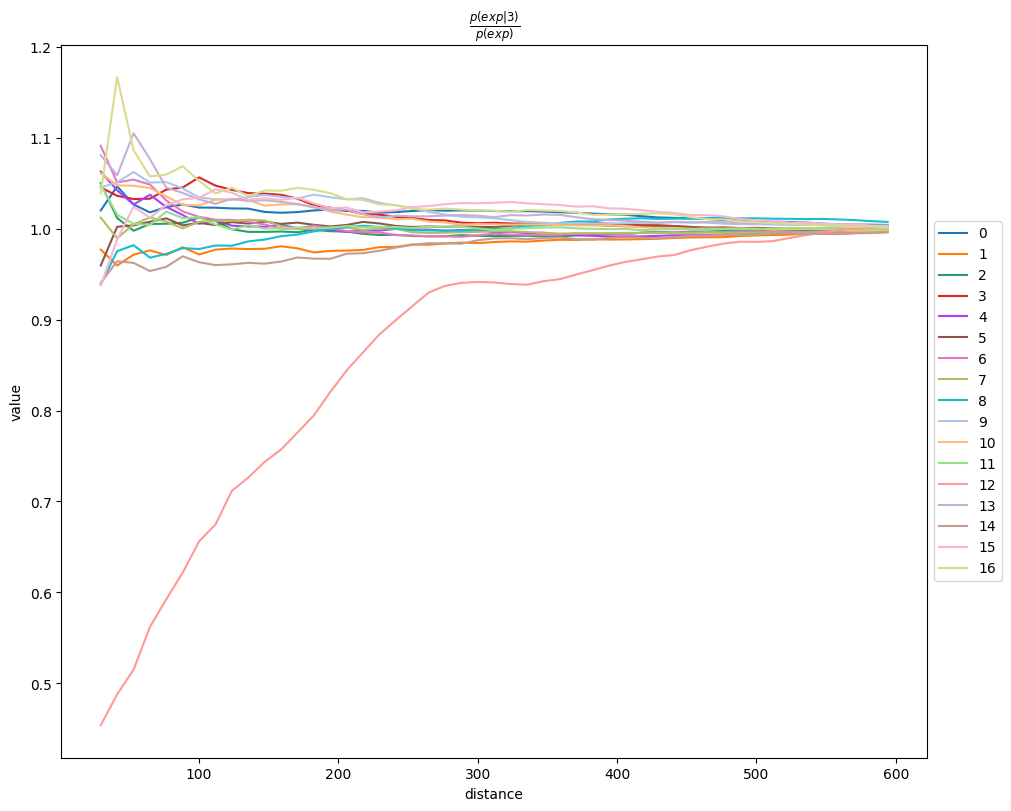

In [18]:
sq.gr.co_occurrence(adata_sub, cluster_key="leiden")

# Pick a cluster guaranteed to exist
clusters_sorted = sorted(adata_sub.obs["leiden"].unique().tolist(), key=int)
cond_cluster = clusters_sorted[min(3, len(clusters_sorted) - 1)]
print(f"Conditioning on cluster: {cond_cluster}")

sq.pl.co_occurrence(
    adata_sub,
    cluster_key="leiden",
    clusters=cond_cluster,
    figsize=(10, 8),
)

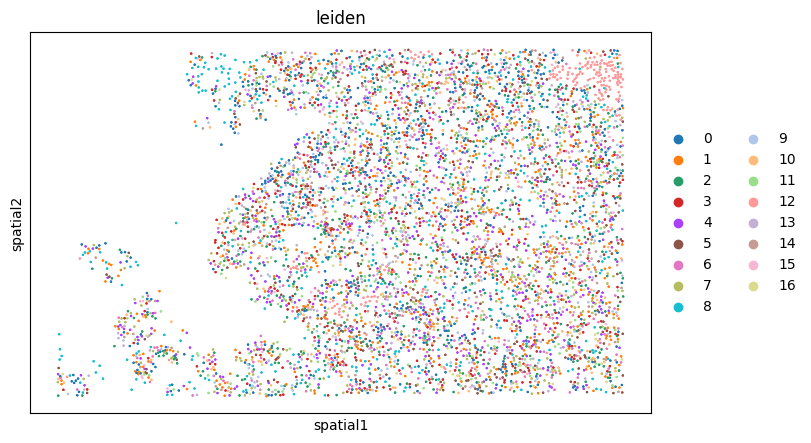

In [19]:
# Spatial scatter of subsampled cells coloured by cluster
sq.pl.spatial_scatter(
    adata_sub,
    color="leiden",
    shape=None,
    size=2,
    figsize=(8, 8),
)

## Cell 16 — Neighbourhood Enrichment

Tests which cluster pairs are **directly connected in the spatial graph more often than chance**. A permutation z-score is returned:

- **High positive z** → clusters frequently neighbour each other (spatially enriched)
- **High negative z** → clusters avoid each other in space (depleted)

Run on the full dataset using the graph from Cell 12.

In [20]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")
print("Neighbourhood enrichment complete.")

  0%|          | 0/1000 [00:00<?, ?/s]

Neighbourhood enrichment complete.


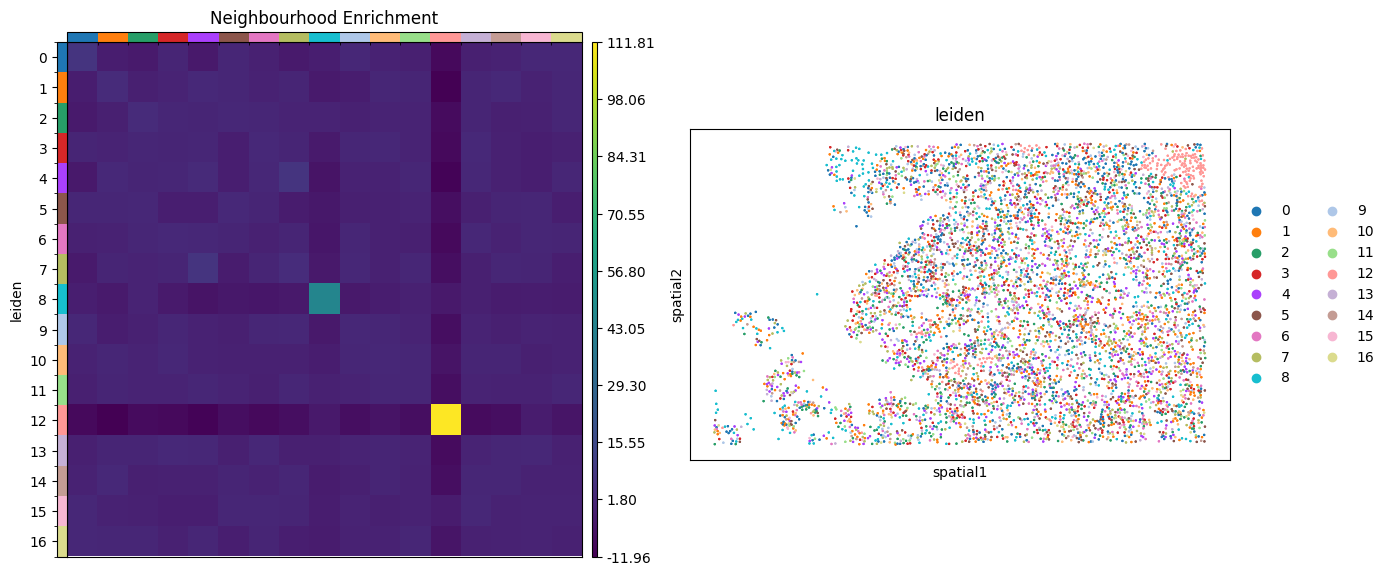

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    title="Neighbourhood Enrichment",
    ax=ax[0],
)

sq.pl.spatial_scatter(
    adata_sub,
    color="leiden",
    shape=None,
    size=2,
    ax=ax[1],
)

plt.tight_layout()
plt.show()

## Cell 17 — Moran's I: Spatially Variable Genes

Moran's I detects genes with **spatially structured expression**:

| Value | Meaning |
|-------|---------|
| ≈ +1 | Strongly clustered — nearby cells share similar expression |
| ≈ 0 | Random distribution across tissue |
| ≈ −1 | Dispersed / checkerboard pattern |

We rebuild the spatial graph on the subsampled data and compute across all genes.

In [22]:
# Spatial graph on subsampled data
sq.gr.spatial_neighbors(adata_sub, coord_type="generic", delaunay=True)

# Compute Moran's I (100 permutations for significance testing)
sq.gr.spatial_autocorr(
    adata_sub,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)

print("Top 10 spatially variable genes:")
adata_sub.uns["moranI"].head(10)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/100 [00:00<?, ?/s]

Top 10 spatially variable genes:


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
GJA5,0.342052,0.0,0.000057,0.0,0.009901,0.000049,0.0,0.0,0.025194
IGFBP3,0.311425,0.0,0.000057,0.0,0.009901,0.000063,0.0,0.0,0.025194
CXCL13,0.255999,0.0,0.000057,0.0,0.009901,0.000058,0.0,0.0,0.025194
ANPEP,0.217560,0.0,0.000057,0.0,0.009901,0.000057,0.0,0.0,0.025194
PLA2G7,0.204977,0.0,0.000057,0.0,0.009901,0.000059,0.0,0.0,0.025194
GPX2,0.199830,0.0,0.000057,0.0,0.009901,0.000052,0.0,0.0,0.025194
MYH11,0.192787,0.0,0.000057,0.0,0.009901,0.000040,0.0,0.0,0.025194
LTBP2,0.187088,0.0,0.000057,0.0,0.009901,0.000049,0.0,0.0,0.025194
DIRAS3,0.163331,0.0,0.000057,0.0,0.009901,0.000051,0.0,0.0,0.025194
AGR3,0.158846,0.0,0.000057,0.0,0.009901,0.000052,0.0,0.0,0.025194


## Cell 18 — Visualise Top Spatially Variable Genes

Plot the top 2 genes by Moran's I on the tissue. High Moran's I genes should display clear regional expression patterns.

Top spatially variable genes: ['GJA5', 'IGFBP3']


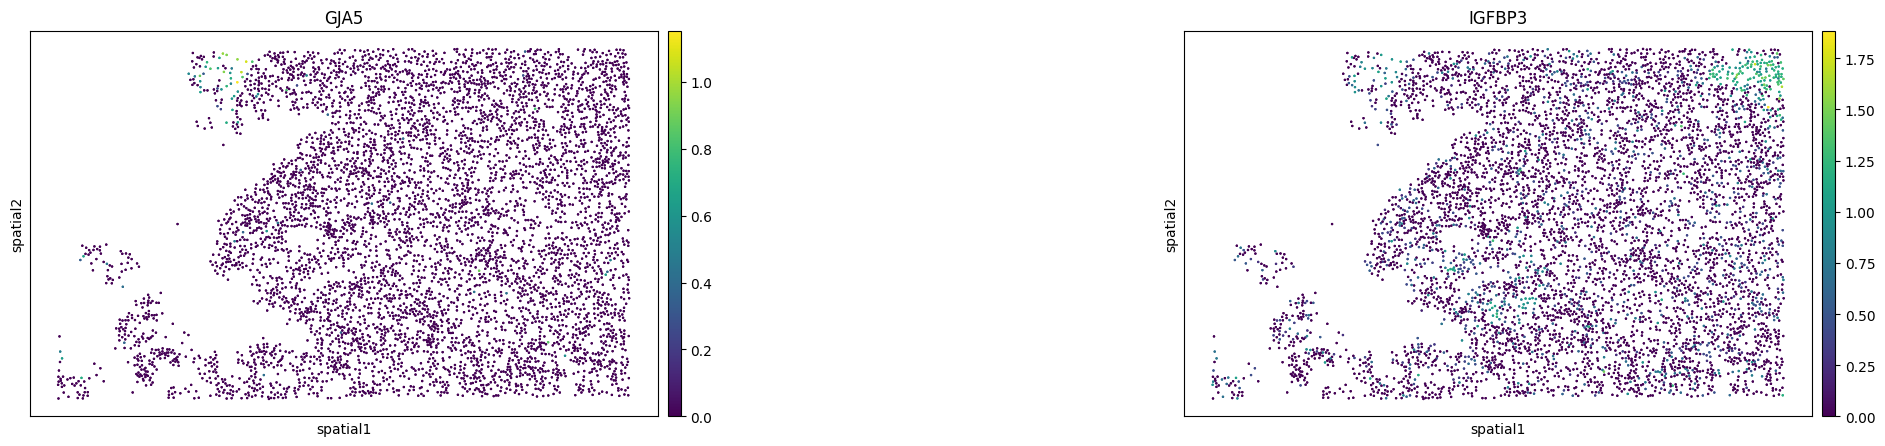

In [23]:
top_genes = adata_sub.uns["moranI"].index[:2].tolist()
print(f"Top spatially variable genes: {top_genes}")

sq.pl.spatial_scatter(
    adata_sub,
    library_id="spatial",
    color=top_genes,
    shape=None,
    size=2,
    img=False,
    figsize=(12, 5),
)

## Cell 19 — Results Summary

All results are stored in the AnnData objects:

| Analysis | Location |
|----------|----------|
| QC metrics | `adata.obs` columns (`total_counts`, `n_genes_by_counts`, `cell_area` …) |
| Leiden clusters | `adata.obs["leiden"]` |
| UMAP embedding | `adata.obsm["X_umap"]` |
| Spatial graph | `adata.obsp["spatial_connectivities"]` |
| Centrality scores | `adata.uns["leiden_centrality_scores"]` |
| Co-occurrence | `adata_sub.uns["leiden_co_occurrence"]` |
| Neighbourhood enrichment | `adata.uns["leiden_nhood_enrichment"]` |
| Moran's I | `adata_sub.uns["moranI"]` |

### Possible next steps
- Annotate clusters using known lung markers: `EPCAM` (epithelial), `CD3D` (T cells), `CD68` (macrophages)
- Ligand-receptor: `sq.gr.ligrec(adata, cluster_key="leiden")`
- Multi-modal integration with paired Visium data

In [24]:
print("=== Final AnnData ===")
print(adata)
print("\n=== Stored analysis results ===")
print(list(adata.uns.keys()))

=== Final AnnData ===
AnnData object with n_obs × n_vars = 11820 × 285
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'spatialdata_attrs', 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'spatial_neighbors', 'leiden_centrality_scores', 'leiden_nhood_enrichment'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities', 'sp